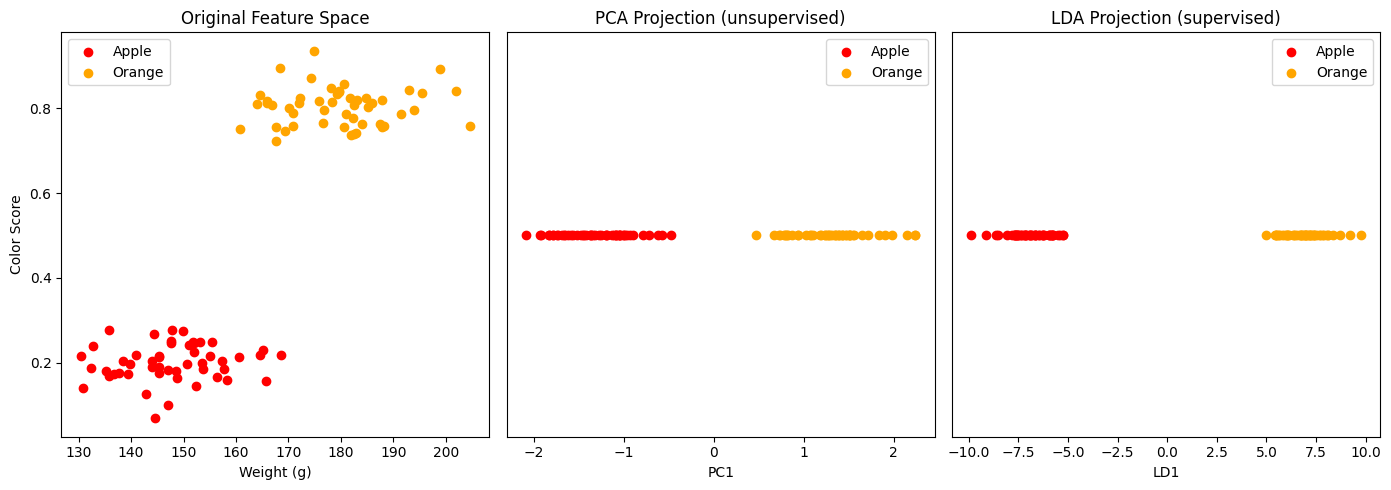

PCA explained variance ratio: [0.92615878]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import StandardScaler

# -------------------------------
# 1. Create synthetic Apple vs Orange dataset
# -------------------------------
np.random.seed(42)

# Apples: mean ~ (weight=150g, color=0.2)
apple_weight = np.random.normal(150, 10, 50)
apple_color = np.random.normal(0.2, 0.05, 50)

# Oranges: mean ~ (weight=180g, color=0.8)
orange_weight = np.random.normal(180, 10, 50)
orange_color = np.random.normal(0.8, 0.05, 50)

X = np.vstack([
    np.column_stack([apple_weight, apple_color]),
    np.column_stack([orange_weight, orange_color])
])
y = np.array([0]*50 + [1]*50)  # 0=apple, 1=orange

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# 2. PCA (unsupervised)
# -------------------------------
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X_scaled)

# -------------------------------
# 3. LDA (supervised)
# -------------------------------
lda = LDA(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)

# -------------------------------
# 4. Plot results
# -------------------------------
plt.figure(figsize=(14,5))

# Original data
plt.subplot(1,3,1)
plt.scatter(X[y==0,0], X[y==0,1], c='red', label='Apple')
plt.scatter(X[y==1,0], X[y==1,1], c='orange', label='Orange')
plt.xlabel("Weight (g)")
plt.ylabel("Color Score")
plt.title("Original Feature Space")
plt.legend()

# PCA projection
plt.subplot(1,3,2)
plt.scatter(X_pca[y==0], np.zeros_like(X_pca[y==0]), c='red', label='Apple')
plt.scatter(X_pca[y==1], np.zeros_like(X_pca[y==1]), c='orange', label='Orange')
plt.title("PCA Projection (unsupervised)")
plt.xlabel("PC1")
plt.yticks([])
plt.legend()

# LDA projection
plt.subplot(1,3,3)
plt.scatter(X_lda[y==0], np.zeros_like(X_lda[y==0]), c='red', label='Apple')
plt.scatter(X_lda[y==1], np.zeros_like(X_lda[y==1]), c='orange', label='Orange')
plt.title("LDA Projection (supervised)")
plt.xlabel("LD1")
plt.yticks([])
plt.legend()

plt.tight_layout()
plt.show()

# Print explained variance for PCA
print("PCA explained variance ratio:", pca.explained_variance_ratio_)


📌 PCA Results
Eigenvalues (explained variance): [1.87102784 0.14917418]
Explained variance ratio: [0.92615878 0.07384122]
Eigenvectors (principal components):
 [[ 0.70710678  0.70710678]
 [ 0.70710678 -0.70710678]]

📌 LDA Results
Class means after scaling:
 [[-0.85517793 -0.98964125]
 [ 0.85517793  0.98964125]]
Coefficients (linear discriminants / eigenvector): [[ 4.1646009  92.90142875]]
Explained variance ratio (importance of LDs): [1.]


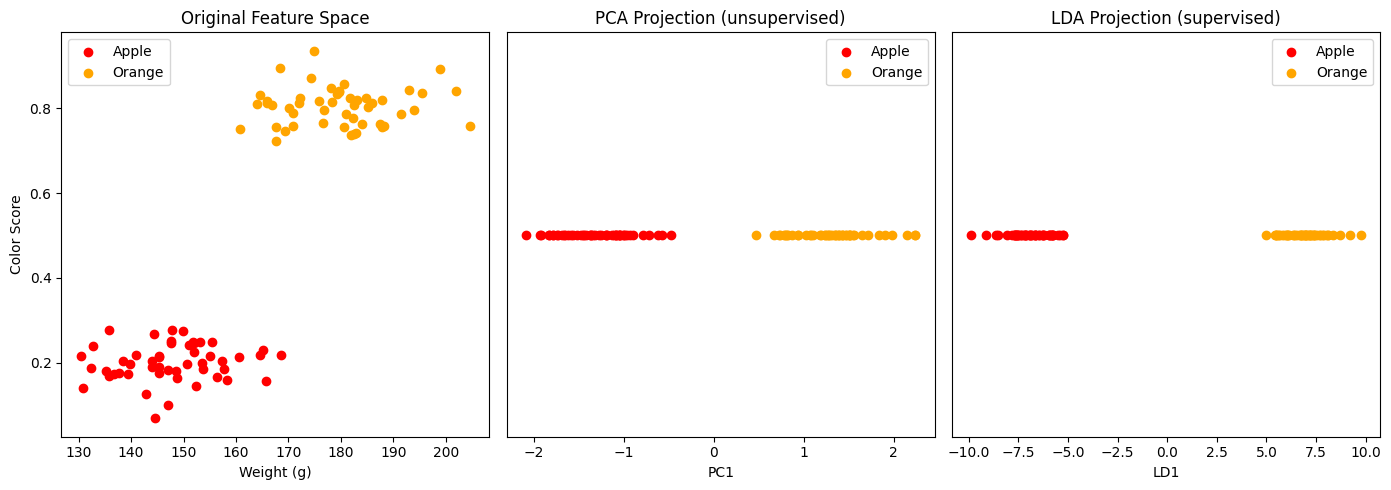

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import StandardScaler

# -------------------------------
# 1. Create synthetic Apple vs Orange dataset
# -------------------------------
np.random.seed(42)

# Apples: mean ~ (weight=150g, color=0.2)
apple_weight = np.random.normal(150, 10, 50)
apple_color = np.random.normal(0.2, 0.05, 50)

# Oranges: mean ~ (weight=180g, color=0.8)
orange_weight = np.random.normal(180, 10, 50)
orange_color = np.random.normal(0.8, 0.05, 50)

X = np.vstack([
    np.column_stack([apple_weight, apple_color]),
    np.column_stack([orange_weight, orange_color])
])
y = np.array([0]*50 + [1]*50)  # 0=apple, 1=orange

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# 2. PCA (unsupervised)
# -------------------------------
pca = PCA(n_components=2)  # keep both for inspection
X_pca = pca.fit_transform(X_scaled)

print("\n📌 PCA Results")
print("Eigenvalues (explained variance):", pca.explained_variance_)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Eigenvectors (principal components):\n", pca.components_)

# -------------------------------
# 3. LDA (supervised)
# -------------------------------
lda = LDA(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)

print("\n📌 LDA Results")
print("Class means after scaling:\n", lda.means_)
print("Coefficients (linear discriminants / eigenvector):", lda.coef_)
print("Explained variance ratio (importance of LDs):", lda.explained_variance_ratio_)

# -------------------------------
# 4. Plot results
# -------------------------------
plt.figure(figsize=(14,5))

# Original data
plt.subplot(1,3,1)
plt.scatter(X[y==0,0], X[y==0,1], c='red', label='Apple')
plt.scatter(X[y==1,0], X[y==1,1], c='orange', label='Orange')
plt.xlabel("Weight (g)")
plt.ylabel("Color Score")
plt.title("Original Feature Space")
plt.legend()

# PCA projection (1D)
plt.subplot(1,3,2)
plt.scatter(X_pca[y==0,0], np.zeros_like(X_pca[y==0,0]), c='red', label='Apple')
plt.scatter(X_pca[y==1,0], np.zeros_like(X_pca[y==1,0]), c='orange', label='Orange')
plt.title("PCA Projection (unsupervised)")
plt.xlabel("PC1")
plt.yticks([])
plt.legend()

# LDA projection (1D)
plt.subplot(1,3,3)
plt.scatter(X_lda[y==0], np.zeros_like(X_lda[y==0]), c='red', label='Apple')
plt.scatter(X_lda[y==1], np.zeros_like(X_lda[y==1]), c='orange', label='Orange')
plt.title("LDA Projection (supervised)")
plt.xlabel("LD1")
plt.yticks([])
plt.legend()

plt.tight_layout()
plt.show()


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("omegajoctan/lda-and-pca-components")

print("Path to dataset files:", path)

100%|██████████| 2.68k/2.68k [00:00<00:00, 6.50MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/omegajoctan/lda-and-pca-components/versions/1


In [3]:
import pandas as pd
import os

# Path to dataset
dataset_path = "/root/.cache/kagglehub/datasets/omegajoctan/lda-and-pca-components/versions/1"

# List files to see what's inside
print(os.listdir(dataset_path))

# Load CSV (adjust filename if different)
df = pd.read_csv(os.path.join(dataset_path, "lda_pca.csv"))  # replace with actual filename
print(df.head())


['iris-data pca-components.csv', 'iris-data lda-components.csv']


FileNotFoundError: [Errno 2] No such file or directory: '/root/.cache/kagglehub/datasets/omegajoctan/lda-and-pca-components/versions/1/lda_pca.csv'

In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
import pandas as pd
# Step 2: Define the path to the CSV file
csv_path = '/content/drive/MyDrive/ml lab/iris-data lda-components.csv'

# Step 3: Read the CSV using pandas
df = pd.read_csv(csv_path)

# Step 4: Display the data
print("CSV file read successfully!")
df.head()


CSV file read successfully!


,None,None.1
0,-1.05806,2.67690
1,-1.06078,2.53215
2,-0.91399,2.77796
3,-0.76139,2.62821
4,-0.95714,2.76343


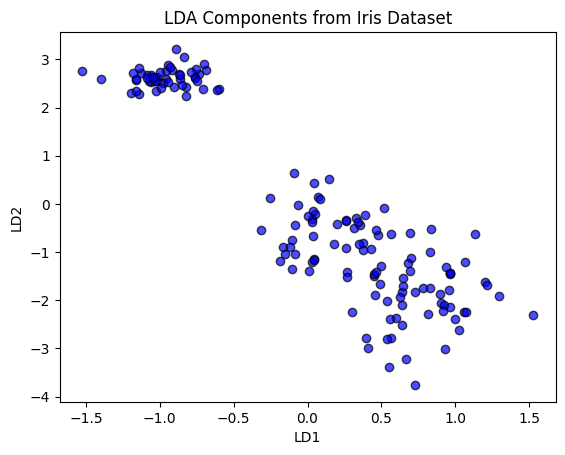

In [6]:
import matplotlib.pyplot as plt


df.columns = ["LD1", "LD2"]


plt.scatter(df["LD1"], df["LD2"], c='blue', alpha=0.7, edgecolor='k')
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA Components from Iris Dataset")
plt.show()


In [7]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Load iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# LDA
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

print("PCA explained variance ratio:", pca.explained_variance_ratio_)
print("LDA explained variance ratio:", lda.explained_variance_ratio_)


PCA explained variance ratio: [0.72962445 0.22850762]
LDA explained variance ratio: [0.9912126 0.0087874]


In [8]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Standardize
X_scaled = StandardScaler().fit_transform(X)

# PCA
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

print("Eigenvalues (variance explained):", pca.explained_variance_)
print("Eigenvectors (principal components):\n", pca.components_)


Eigenvalues (variance explained): [2.93808505 0.9201649  0.14774182 0.02085386]
Eigenvectors (principal components):
 [[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]
 [ 0.71956635 -0.24438178 -0.14212637 -0.63427274]
 [-0.26128628  0.12350962  0.80144925 -0.52359713]]
